# Segmentación de cultivos con AnySat (congelado) sobre PASTIS-R

Se entrena un segmentador basado en AnySat (Astruc et al., 2024), un modelo fundacional para datos de observación de la Tierra. AnySat se usa congelado, como extractor de características, y solo se entrena una cabeza lineal que las proyecta a las clases de cultivo; el entrenamiento es barato porque el grueso de los pesos no se actualiza.

Este cuaderno corre de forma independiente (en paralelo con el de U-Net) y deja sus artefactos en carpetas del Drive compartido para el reporte: la tabla de métricas, la figura de la matriz de confusión y el modelo entrenado.

## Datos y métricas

PASTIS-R entrega parches Sentinel-2 multitemporales de 128x128, que aquí se reescalan a 64 (la resolución densa viable para AnySat: su atención crece de forma cuadrática con el número de tokens espaciales, por lo que 256 no cabe en memoria). Las etiquetas tienen 20 clases: fondo, 18 tipos de cultivo y una clase void que se descarta en la pérdida y en las métricas. El split de entrenamiento y validación usa los folds oficiales del dataset, espacialmente disjuntos. Se reportan mIoU, F1-macro y exactitud a nivel de píxel en dos esquemas: las 18 clases planas y los 6 grupos agronómicos HCAT (cereales, oleaginosas, tubérculos, leguminosas, leñosos y otros), siendo este último el comparable con el baseline del avance anterior.

In [1]:
# Environment setup. On Colab, Drive is mounted (where the dataset lives) and the
# dependencies not bundled by default are installed; not needed locally.
import os, sys, subprocess
from pathlib import Path

_IN_COLAB = False
shared_folder_path = ''
try:
    from google.colab import drive
    drive.mount('/content/drive')
    shared_folder_path = '/content/drive/MyDrive/Integrador/'
    _IN_COLAB = True
except ImportError:
    pass

# On Colab the repo is not present: it is cloned once into /content/agrosat-copilot.
if _IN_COLAB:
    from getpass import getpass
    _repo_dir = '/content/agrosat-copilot'
    _branch = 'main'
    _repo = 'github.com/ArthurZizumbo/agrosat-copilot.git'
    if not Path(_repo_dir, 'pyproject.toml').is_file():
        _rc = os.system(f'git clone --branch {_branch} --depth 1 https://{_repo} {_repo_dir}')
        if _rc != 0:  # private repo: ask for token (not stored in the notebook)
            _tok = getpass('GitHub token (repo privado): ')
            os.system(f'git clone --branch {_branch} --depth 1 https://{_tok}@{_repo} {_repo_dir}')

# The code does not live in Drive: locate the repo by its pyproject.toml.
_search = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
if _IN_COLAB:
    _search = [Path('/content/agrosat-copilot'), *_search]
for _cand in _search:
    if (_cand / 'pyproject.toml').is_file():
        if str(_cand) not in sys.path:
            sys.path.insert(0, str(_cand))
        os.chdir(_cand)
        break
else:
    raise RuntimeError('No se encontro el repo agrosat-copilot (pyproject.toml). '
                       'Clonalo en /content/agrosat-copilot o sincronizalo desde VS Code.')

if _IN_COLAB:
    subprocess.run([sys.executable, '-m', 'pip', '-q', 'install',
                    'segmentation-models-pytorch', 'structlog', 'typer', 'polars', 'mlflow'], check=False)

print('repo:', Path.cwd(), '| colab:', _IN_COLAB, '| drive:', shared_folder_path or '(local)')

repo: F:\projects\agrosat-copilot | colab: False | drive: (local)


In [2]:
# Run configuration.
import os

import torch

MODEL = 'anysat'
# The dataset lives in Drive; locally the repo copy is used.
PASTIS_ROOT = Path((shared_folder_path + 'data/PASTIS-R') if shared_folder_path
                   else 'data/PASTIS-R')
# Artifact folders in Drive (clear names so they can be cited in the report):
#   reports/segmentation/metrics      -> parquet with metrics per model
#   reports/segmentation/figures      -> PNG of the confusion matrix
#   reports/segmentation/checkpoints  -> final model + resumable checkpoint
SEG_DIR = Path((shared_folder_path if shared_folder_path else '') + 'reports/segmentation')
METRICS_DIR = SEG_DIR / 'metrics'
FIGURES_DIR = SEG_DIR / 'figures'
CHECKPOINT_DIR = SEG_DIR / 'checkpoints'
for _d in (METRICS_DIR, FIGURES_DIR, CHECKPOINT_DIR):
    _d.mkdir(parents=True, exist_ok=True)
COMPARISON_PATH = METRICS_DIR / f'model_comparison_avance4_{MODEL}.parquet'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
# AnySat is a ViT whose attention cost grows quadratically with the number of
# spatial tokens. At 256 px it asks for >190 GiB and does not fit on any GPU
# (not even the 96 GB H100); 64 px is the viable dense resolution, the same the
# AnySat fast notebook (04h) uses. BATCH must be 1 at this resolution.
TARGET_SIZE = 64
SUBSET = int(os.environ.get('SEG_SUBSET', '0'))   # 0 = all; reduce for a quick smoke
EPOCHS = int(os.environ.get('SEG_EPOCHS', '30'))
BATCH = 1
MLFLOW_URI = os.environ.get('MLFLOW_URI', 'file:./mlruns')
# By default it reads directly from Drive (no copy). If you will train many epochs and
# prefer to speed it up, set COPY_TO_LOCAL=True (copies once to the ephemeral disk).
COPY_TO_LOCAL = False
# DataLoader parallelism. AnySat is GPU-bound (the ViT encoder runs frozen), so
# fewer workers are needed than U-Net; the intra-op pool is capped so the two
# parallel trainings do not oversubscribe the 40 cores. Parametrized via env vars.
NUM_WORKERS = int(os.environ.get('SEG_NUM_WORKERS', '4'))
torch.set_num_threads(int(os.environ.get('TORCH_NUM_THREADS', '4')))

print('modelo:', MODEL, '| device:', DEVICE, '| batch:', BATCH, '| target_size:', TARGET_SIZE,
      '| num_workers:', NUM_WORKERS, '| torch_threads:', torch.get_num_threads())
print('PASTIS_ROOT:', PASTIS_ROOT, '| exists:', PASTIS_ROOT.exists())
print('mlflow:', MLFLOW_URI, '| artefactos en:', SEG_DIR)

modelo: anysat | device: cuda | batch: 1 | target_size: 64 | num_workers: 4 | torch_threads: 4
PASTIS_ROOT: data\PASTIS-R | exists: True
mlflow: http://127.0.0.1:5010 | artefactos en: reports\segmentation


## Lectura del dataset

Por defecto el dataset se lee directo desde Drive, sin copiar nada: así se evita la espera inicial y no se pierde trabajo si la sesión se reinicia. El loader abre cada parche con un solo acceso a disco (no relee el archivo de metadatos en cada paso) y el DataLoader usa varios procesos en paralelo. Si preferís acelerar, poné `COPY_TO_LOCAL = True` en la celda anterior para copiar una vez al disco local de la sesión.

In [3]:
# Copy the dataset from Drive to the local disk, with a progress bar.
import shutil, time

def copy_pastis_to_local(src_root, dst_root,
                         subdirs=('DATA_S2', 'ANNOTATIONS'),
                         files=('metadata.geojson', 'NORM_S2_patch.json')):
    src_root, dst_root = Path(src_root), Path(dst_root)
    dst_root.mkdir(parents=True, exist_ok=True)
    todo = []
    for sub in subdirs:
        for f in sorted((src_root / sub).glob('*')):
            if f.is_file():
                todo.append((f, dst_root / sub / f.name))
    for fname in files:
        sp = src_root / fname
        if sp.is_file():
            todo.append((sp, dst_root / fname))
    if not todo:
        raise FileNotFoundError(f'No se hallaron DATA_S2/ANNOTATIONS en {src_root}')
    total_bytes = sum(s.stat().st_size for s, _ in todo)
    try:
        from tqdm.auto import tqdm
        bar = tqdm(total=total_bytes, unit='B', unit_scale=True, desc='Copiando PASTIS')
    except Exception:
        bar = None
    t0 = time.time()
    for i, (src, dst) in enumerate(todo, 1):
        dst.parent.mkdir(parents=True, exist_ok=True)
        # Skip the file if it is already copied with the same size.
        if not (dst.exists() and dst.stat().st_size == src.stat().st_size):
            shutil.copy2(src, dst)
        if bar is not None:
            bar.update(src.stat().st_size)
        elif i % 200 == 0:
            print(f'  {i}/{len(todo)} archivos...')
    if bar is not None:
        bar.close()
    print(f'Listo: {len(todo)} archivos ({total_bytes / 1e9:.1f} GB) en {time.time() - t0:.0f}s -> {dst_root}')
    return dst_root

if _IN_COLAB and COPY_TO_LOCAL:
    PASTIS_ROOT = copy_pastis_to_local(PASTIS_ROOT, '/content/PASTIS-R')
    print('PASTIS_ROOT (local):', PASTIS_ROOT, '| exists:', PASTIS_ROOT.exists())
else:
    print('Lectura directa desde:', PASTIS_ROOT, '| exists:', PASTIS_ROOT.exists())

Lectura directa desde: data\PASTIS-R | exists: True


In [4]:
# Split into the official PASTIS folds (spatially disjoint).
from ml.ingest.pastis_dataset import pastis_fold_split

split = pastis_fold_split(PASTIS_ROOT, train_folds=(1, 2, 3), val_folds=(4,), test_folds=(5,))
print({k: len(v) for k, v in split.items()})

{'train': 1455, 'val': 482, 'test': 496}


## Entrenamiento

AnySat se descarga la primera vez desde su repositorio (torch.hub). El entrenamiento guarda un checkpoint por época en Drive; si la sesión se reinicia, al volver a ejecutar esta celda se reanuda desde la última época completada.

In [5]:
# Load AnySat (torch.hub) and train the linear head.
from ml.train.train_segmentation import run_training
from ml.models.anysat_wrapper import load_anysat_encoder

_ = load_anysat_encoder()  # download and validate the weights before training
result = run_training(
    model=MODEL, epochs=EPOCHS, batch_size=BATCH, target_size=TARGET_SIZE,
    subset=SUBSET, device=DEVICE, root=PASTIS_ROOT, mlflow_uri=MLFLOW_URI,
    comparison_path=COMPARISON_PATH, num_workers=NUM_WORKERS, output_dir=CHECKPOINT_DIR,
)
result

Using cache found in F:\cache\torch\hub\gastruc_anysat_main


2026-06-15 20:39:53 [info     ] anysat_encoder_loaded          pretrained=True repo=gastruc/anysat


Using cache found in F:\cache\torch\hub\gastruc_anysat_main


2026-06-15 20:39:53 [info     ] anysat_encoder_loaded          pretrained=True repo=gastruc/anysat


2026-06-15 20:40:06 [info     ] segmentation_resume            f1_macro=0.6296022951881365 f1_macro_grouped=0.7736103114158445 miou=0.49288858264888014 miou_grouped=0.6492700433806216 model=anysat pixel_accuracy=0.7889171519384844 pixel_accuracy_grouped=0.7672822670141684 start_epoch=30


...

2026-06-15 20:40:06 [warning  ] dvc file ausente, data_version=untracked path=data\PASTIS-R.dvc


2026-06-15 20:40:06 [info     ] mlflow_run_started             code_version=4cda41f48d244992ece653d5d2c29e119b203c2b data_version=data\PASTIS-R@untracked experiment=agrosat-segmentation run_id=86f08aff0577449a98065a39e50a9a83 run_name=seg-anysat-pastis-v1 tracking_uri=http://127.0.0.1:5010


2026-06-15 20:40:07 [warning  ] mlflow_log_artifact_skipped    error="Could not find a registered artifact repository for: f:/mlflow/artifacts/2/86f08aff0577449a98065a39e50a9a83/artifacts. Currently registered schemes are: ['', 'file', 's3', 'r2', 'b2', 'gs', 'wasbs', 'ftp', 'sftp', 'dbfs', 'hdfs', 'viewfs', 'runs', 'models', 'http', 'https', 'mlflow-artifacts', 'abfss']" path=reports\segmentation\checkpoints\anysat_pastis.pt


🏃 View run seg-anysat-pastis-v1 at: http://127.0.0.1:5010/#/experiments/2/runs/86f08aff0577449a98065a39e50a9a83
🧪 View experiment at: http://127.0.0.1:5010/#/experiments/2
2026-06-15 20:40:07 [info     ] segmentation_train_done        f1_macro=0.6296022951881365 f1_macro_grouped=0.7736103114158445 miou=0.49288858264888014 miou_grouped=0.6492700433806216 model=anysat pixel_accuracy=0.7889171519384844 pixel_accuracy_grouped=0.7672822670141684


{'model': 'anysat',
 'miou': 0.49288858264888014,
 'f1_macro': 0.6296022951881365,
 'pixel_accuracy': 0.7889171519384844,
 'miou_grouped': 0.6492700433806216,
 'f1_macro_grouped': 0.7736103114158445,
 'pixel_accuracy_grouped': 0.7672822670141684,
 'train_time_s': 0.3288165999983903,
 'checkpoint_path': 'reports\\segmentation\\checkpoints\\anysat_pastis.pt'}

## Métricas

Tabla de métricas de este modelo sobre el fold de validación, en los dos esquemas (18 clases y 6 grupos HCAT). Se guarda en `reports/segmentation/metrics/`; el notebook integrador la une con la del otro modelo para la comparativa final. Las columnas con sufijo `grouped` corresponden a los 6 grupos (el fondo no entra en esas métricas).

In [6]:
import polars as pl

table = pl.read_parquet(COMPARISON_PATH)
cols = ['model', 'miou_grouped', 'f1_macro_grouped', 'pixel_accuracy_grouped',
        'miou', 'f1_macro', 'pixel_accuracy', 'train_time_s', 'epochs']
table.select([c for c in cols if c in table.columns])

model,miou_grouped,f1_macro_grouped,pixel_accuracy_grouped,miou,f1_macro,pixel_accuracy,train_time_s,epochs
str,f64,f64,f64,f64,f64,f64,f64,i64
"""anysat""",0.64927,0.77361,0.767282,0.492889,0.629602,0.788917,0.328817,30


## Matriz de confusión

Recall por clase a nivel de píxel sobre el fold de validación, sin contar la clase void. La figura se guarda en `reports/segmentation/figures/` para el reporte.

Using cache found in F:\cache\torch\hub\gastruc_anysat_main


2026-06-15 20:40:09 [info     ] anysat_encoder_loaded          pretrained=True repo=gastruc/anysat


Figura guardada en: reports\segmentation\figures\confusion_anysat.png


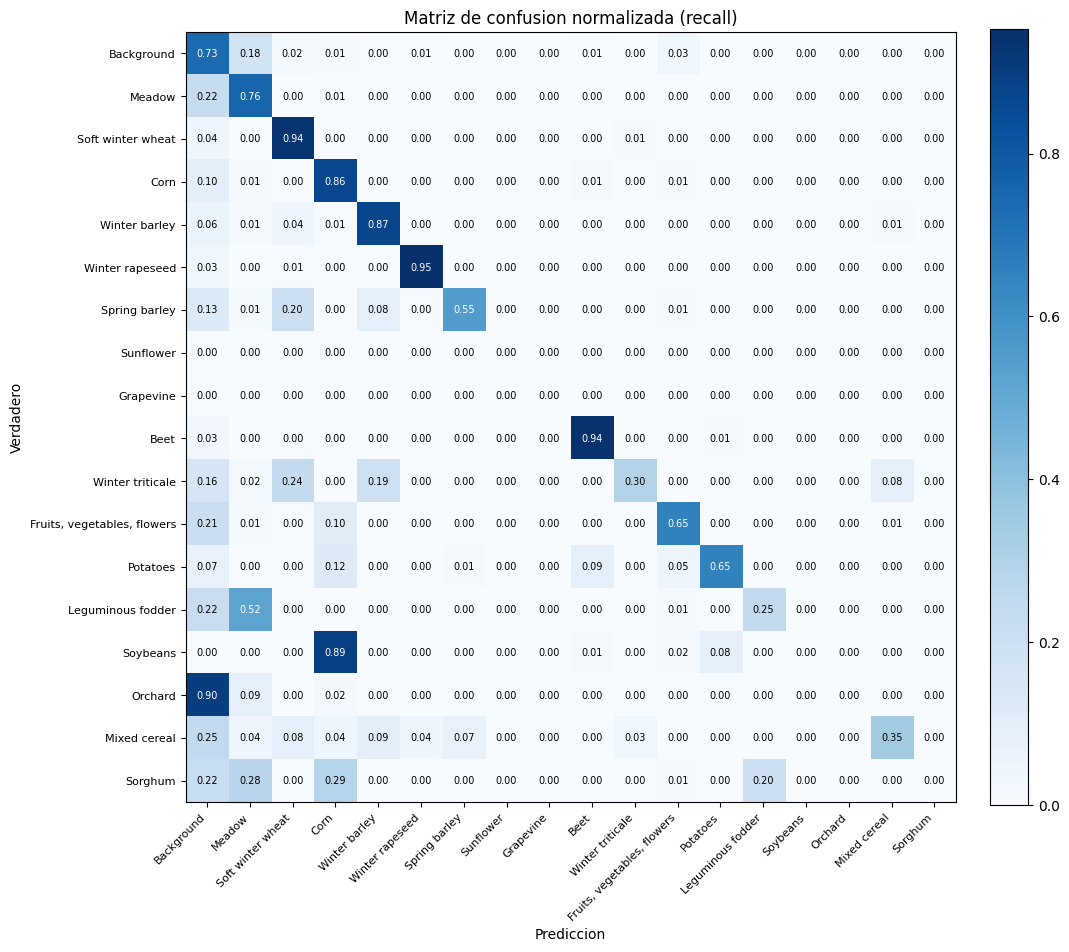

In [7]:
# Pixel-level confusion matrix; saved as PNG in Drive.
%matplotlib inline
import torch
from torch.utils.data import DataLoader
from IPython.display import display
from ml.ingest.pastis_dataset import PASTISDataset, load_norm_stats, PASTIS_IGNORE_INDEX
from ml.ingest.pastis_loader import PASTIS_CLASS_MAP
from ml.eval.dense_metrics import dense_confusion_figure
from ml.models.anysat_wrapper import AnySatSegmenter

def confusion_figure(model_name, reduction, build_fn, ckpt, max_patches=40):
    norm = load_norm_stats(PASTIS_ROOT, folds=(1, 2, 3))
    val_ids = split['val'][:max_patches]
    ds = PASTISDataset(val_ids, root=PASTIS_ROOT, target_size=TARGET_SIZE,
                       temporal_reduction=reduction, norm=norm)
    loader = DataLoader(ds, batch_size=2)
    model = build_fn().to(DEVICE)
    model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    model.eval()
    preds, tgts = [], []
    with torch.no_grad():
        for b in loader:
            img = b['image'].to(DEVICE)
            out = model(img) if model_name == 'unet' else model(img, b['dates'].to(DEVICE))
            preds.append(out.argmax(1).cpu().reshape(-1))
            tgts.append(b['semantic'].reshape(-1))
    return dense_confusion_figure(torch.cat(preds), torch.cat(tgts),
                                  class_names=PASTIS_CLASS_MAP, ignore_index=PASTIS_IGNORE_INDEX)

fig = confusion_figure(MODEL, 'none', lambda: AnySatSegmenter(20, target_size=TARGET_SIZE),
                       result['checkpoint_path'])
_fig_path = FIGURES_DIR / f'confusion_{MODEL}.png'
fig.savefig(_fig_path, bbox_inches='tight', dpi=120)
print('Figura guardada en:', _fig_path)
display(fig)

## Conclusiones

Las métricas y la matriz de confusión quedan guardadas en `reports/segmentation/` (carpetas `metrics/` y `figures/`) y el modelo entrenado en `checkpoints/`. El notebook integrador `Avance4.Equipo17` reúne este modelo con el otro para la comparativa final, elige el de mejor desempeño y, si vale la pena, afina sus hiperparámetros con una búsqueda más fina como la del bloque siguiente.

In [8]:
# Hyperparameter search with Optuna (optional, if this model makes the top tier).
#
# import optuna
# def objective(trial):
#     lr = trial.suggest_float('lr', 1e-5, 1e-3, log=True)
#     wd = trial.suggest_float('weight_decay', 1e-6, 1e-2, log=True)
#     res = run_training(model=MODEL, epochs=15, batch_size=BATCH, lr=lr, weight_decay=wd,
#                        target_size=TARGET_SIZE, subset=SUBSET, device=DEVICE,
#                        root=PASTIS_ROOT, mlflow_uri=MLFLOW_URI, resume=False)
#     return res['miou_grouped']
# study = optuna.create_study(direction='maximize', study_name=f'tune-{MODEL}')
# study.optimize(objective, n_trials=30)
# study.best_params